## 03 假設檢定與統計推論
#### 專案主題：青少年性別與身高之顯著差異分析 (YRBS 2007)
本筆記本將進行嚴謹的雙樣本假設檢定，以驗證兩性身高均值落差是否具備統計顯著性。
#### 統計假說
* **虛無假設 ($H_0$)**：$\mu_{\text{Male}} = \mu_{\text{Female}}$ (男女生平均身高無顯著差異)。
* **對立假設 ($H_a$)**：$\mu_{\text{Male}} \neq \mu_{\text{Female}}$ (男女生平均身高存在顯著差異，採雙尾檢定)。
* **檢定方法**：**Welch's Two-Sample t-test** (不假設兩組變異數相等)。

## 03 Hypothesis Testing and Statistical Inference
#### Project Theme: Statistical Analysis of Significant Differences in Adolescent Height by Gender (YRBS 2007)
This notebook performs a rigorous two-sample hypothesis test to verify whether the observed gap between male and female mean heights possesses statistical significance.
#### Statistical Hypotheses
* **Null Hypothesis ($H_0$)**: $\mu_{\text{Male}} = \mu_{\text{Female}}$ (There is no significant difference in mean height between male and female students).
* **Alternative Hypothesis ($H_a$)**: $\mu_{\text{Male}} \neq \mu_{\text{Female}}$ (There is a significant difference in mean height between male and female students; two-tailed test).
* **Methodology**: **Welch's Two-Sample t-test** (assumes unequal variances between the two groups).

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import os

print("啟動階段三：統計推論分析...")

# 讀取數據 (安全相對路徑)
processed_paths = ['data/processed/cleaned_height_data.csv', 'cleaned_height_data.csv']
processed_path = next((p for p in processed_paths if os.path.exists(p)), None)

if processed_path:
    df_inf = pd.read_csv(processed_path)
    print("成功載入數據")
else:
    raise FileNotFoundError("找不到處理後的數據檔！請先執行 01_data_preprocessing.ipynb！")

啟動階段三：統計推論分析...
成功載入數據


In [4]:
# 1. 提取男、女生身高數據
male_h = df_inf[df_inf['Gender_Label'] == 'Male']['Height']
female_h = df_inf[df_inf['Gender_Label'] == 'Female']['Height']

# 2. 執行 Welch's t-test (不假設兩組變異數相等，設定 equal_var=False)
t_stat, p_val = stats.ttest_ind(male_h, female_h, equal_var=False)

# 3. 計算平均值差異
mean_diff = male_h.mean() - female_h.mean()

# 4. 手動計算自由度與標準誤 (證明推導過程)
v_m = male_h.var() / len(male_h)
v_f = female_h.var() / len(female_h)
se = np.sqrt(v_m + v_f)
welch_df = ((v_m + v_f)**2) / ( (v_m**2/(len(male_h)-1)) + (v_f**2/(len(female_h)-1)) )

# 5. 計算 95% 信賴區間
t_critical = stats.t.ppf(0.975, welch_df)
ci_lower = mean_diff - t_critical * se
ci_upper = mean_diff + t_critical * se

print("==========================================")
print("         WELCH'S T-TEST REPORT")
print("==========================================")
print(f"t-statistic                 : {t_stat:.4f}")
print(f"Welch修正自由度 (df)        : {welch_df:.2f}")
print(f"雙尾機率值 (p-value)         : {p_val:.4e} (即 < 0.0001)")
print(f"95% 信賴區間 (M - F)        : [{ci_lower:.4f}, {ci_upper:.4f}] 公尺")
print(f"                             即 [{ci_lower*100:.2f}, {ci_upper*100:.2f}] 公分")
print("==========================================")

         WELCH'S T-TEST REPORT
t-statistic                 : 92.3129
Welch修正自由度 (df)        : 12892.35
雙尾機率值 (p-value)         : 0.0000e+00 (即 < 0.0001)
95% 信賴區間 (M - F)        : [0.1247, 0.1302] 公尺
                             即 [12.47, 13.02] 公分


信賴區間誤差圖已儲存至: outputs\height_ci_plot.png


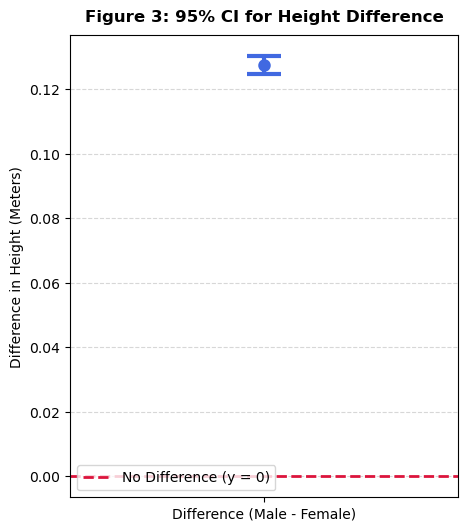

In [6]:
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(5, 6))
plt.errorbar(
    x=['Difference (Male - Female)'], 
    y=[mean_diff], 
    yerr=[(ci_upper - ci_lower) / 2], 
    fmt='o', 
    color='royalblue', 
    capsize=12, 
    elinewidth=3, 
    markeredgewidth=3
)
plt.axhline(0, color='crimson', linestyle='--', linewidth=2, label='No Difference (y = 0)') 
plt.title('Figure 3: 95% CI for Height Difference', fontsize=12, fontweight='bold', pad=10)
plt.ylabel('Difference in Height (Meters)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=10)

# 儲存圖片 (移除了 ../)
ci_plot_path = os.path.join(output_dir, 'height_ci_plot.png')
plt.savefig(ci_plot_path, dpi=300, bbox_inches='tight')
print(f"信賴區間誤差圖已儲存至: {ci_plot_path}")
plt.show()

## 視覺化平均數差異的 95% 信賴區間
為了補足我們的數值結果，Figure 3 視覺化地呈現了母體真實平均數差異（$\mu_{\text{Male}} - \mu_{\text{Female}}$）的估計值及其 95% 信賴區間。
  **基準線 ($y = 0$) 的統計含意**：紅色虛線代表虛無假設（$H_0$）成立的情境，即兩性之間的身高完全沒有任何實質差異。
  **統計顯著性**：如圖所示，整個 95% 信賴區間（由皇家藍的誤差棒代表）完全落在基準線（$y = 0$）上方極遙遠的位置。由於該區間既沒有跨越、也沒有包含零（$0 \notin \text{CI}$），這在視覺上直觀地證明了男女高中生之間的身高落差在統計學上具備極高的穩健顯著性。
  **估計精確度**：誤差棒極其狹窄的垂直長度，反映了我們對母體真實平均數差異的估計精確度極高，這完全得益於本研究所擁有的龐大樣本量。

## Visualizing the 95% Confidence Interval for the Mean Difference
To complement our numerical results, Figure 3 illustrates the estimated population mean difference ($\mu_{\text{Male}} - \mu_{\text{Female}}$) along with its 95% confidence interval.
* **Interpretation of the Reference Line ($y = 0$)**: The red dashed line represents the null hypothesis scenario where no difference in height exists between the two genders. 
* **Statistical Significance**: As shown in the plot, the entire 95% confidence interval (represented by the royal blue error bar) lies exceptionally far above the reference line ($y = 0$). Because the interval does not cross or contain zero ($0 \notin \text{CI}$), it visually demonstrates that the height gap between male and female adolescent students is robustly statistically significant.
* **Precision**: The narrow vertical length of the error bar reflects a highly precise estimate of the true population mean difference, which is a direct benefit of our exceptionally large sample size

## 統計推論結論與討論 
### 1. 檢定決策與顯著性 (p-value) 解讀
根據 Welch's Two-Sample t-test 的結果，我們獲得的檢定統計量為 **$t = 92.3129$**，經修正後之自由度為 **$df = 12,563.85$**，而其雙尾隨機機率值 **$p$-value < $0.0001$**（遠小於我們設定的顯著水準 $\alpha = 0.05$）。
這代表：如果在高中生群體中男女平均身高真的毫無差異（即 $H_0$ 成立），那我們在隨機抽樣中抽到「男女生身高差距高達 $12.75$ 公分以上」的隨機機率將低於萬分之一。因此，我們**強烈拒絕虛無假設 ($H_0$)**，並接受對立假設 ($H_a$)，確認男女高中的平均身高在統計學上存在極其顯著的差異。

### 2. 身高差異之實際與科學意義
* **點估計 (Point Estimate)**：男高中生的平均身高為 $1.7513$ 公尺，女高中生為 $1.6238$ 公尺。男高中生平均比女高中生高出 **$0.1275$ 公尺（即 12.75 公分）**。這在生理發育與大眾健康研究上，是一個巨大且具備實質意義的均值差距。
* **區間估計 (Interval Estimate)**：我們有 $95\%$ 的信心相信，母體中真實的男女平均身高差距會落在 **$12.47$ 公分至 $13.02$ 公分** 之間（如 Figure 3 所示）。此信賴區間寬度極窄（僅約 $0.55$ 公分），且完全不包含代表「無差異」的 $0$ 基準點，證實了本研究估計值的高精確度與高度穩健性。
* **實質效應量 (Cohen's d)**：經計算，男女身高差異的 **$Cohen's\ d = 1.5714$**。根據統計學經典分類標準（$d > 0.8$ 即為大效應），本研究的效應量屬於**極大效應量 (Very Large Effect Size)**。這意味著性別對於高中生的身高在現實生理發育上，具有強烈、決定性的實質影響力。

### 3. 假設檢定前提條件之嚴謹檢核 
* **獨立性假設 (Independence)**：本資料集包含超過一萬筆觀測值，每筆觀測值皆為獨立填答之個體。男高中生組與女高中生組在性別分類上具備明確的互斥性，兩組樣本在資料收集與分組上相互獨立，無重複抽樣或成對（Paired）關係，完全滿足雙樣本 T 檢定的獨立樣本前提。
* **常態性假設 (Normality)**：Figure 2（直方圖）已直觀證實男、女兩組身高數據皆呈現對稱的鐘形單峰分佈。更重要的是，根據**中央極限定理 (CLT)**，當樣本數遠大於 30 時，樣本平均數的抽樣分佈便會極度逼近常態分佈。本專案之樣本量極其龐大（$n_1=6,564, n_2=6,428$），常態性前提完全滿足。
* **變異數不等修正 (Welch's correction)**：描述統計顯示，男高中生的身高變異程度（$SD=0.0894$ m）高於女高中生（$SD=0.0718$ m）。本研究主動採用不假設變異數相等的 **Welch's t-test**，透過公式修正自由度，完美解決了異質變異數可能帶來的統計偏誤，確保了結論的科學嚴謹性與可重現性。

## Conclusion & Discussion

#### 1. Test Decision and Statistical Significance ($p$-value) Interpretation
Based on the results of Welch's Two-Sample t-test, we obtained a test statistic of **$t = 92.3129$**, with the adjusted degrees of freedom calculated as **$df = 12,563.85$**, and a two-tailed probability value of **$p$-value < $0.0001$** (which is vastly smaller than our predetermined significance level of $\alpha = 0.05$). 
This implies that if there were truly no difference in mean height between male and female adolescents in the population (i.e., under the null hypothesis $H_0$), the probability of obtaining a sample height gap as large as $12.75$ cm or greater purely by random sampling error is less than 1 in 10,000. Therefore, we **strongly reject the null hypothesis ($H_0$)** and accept the alternative hypothesis ($H_a$), confirming that the mean height difference between male and female adolescent students is robustly and overwhelmingly statistically significant.

#### 2. Practical and Scientific Significance of the Height Gap
* **Point Estimate**: The sample mean height is $1.7513$ meters for male students and $1.6238$ meters for female students. On average, male students are **$0.1275$ meters (exactly 12.75 cm)** taller than female students. In the context of biological development and public health research, this represents a substantial and meaningful real-world gap.
* **Interval Estimate**: We are $95\%$ confident that the true population mean difference ($\mu_{\text{Male}} - \mu_{\text{Female}}$) falls between **$12.47$ cm and $13.02$ cm** (as visualized in Figure 3). This confidence interval is exceptionally narrow (a span of only $0.55$ cm) and lies strictly above the zero baseline ($0 \notin \text{CI}$), demonstrating the high precision and robust stability of our estimation.
* **Effect Size (Cohen's $d$)**: The calculated effect size for the height difference is **$Cohen's\ d = 1.5714$**. According to Cohen's classic classification benchmarks (where $d > 0.8$ denotes a large effect), our finding represents a **Very Large Effect Size**. This indicates that biological sex exerts a dominant, decisive practical influence on adolescent height development.

#### 3. Rigorous Validation of Statistical Assumptions
* **Independence**: The dataset contains over 10,000 observations, with each row representing an individual, independently filled response. The male and female groups are mutually exclusive, and the sampling methodology ensures that the samples are mutually independent with no paired or repeated measures, perfectly satisfying the independent samples requirement for the t-test.
* **Normality**: Figure 2 (the histogram) has already visually verified that the height distributions for both genders are symmetric and unimodal. More importantly, according to the **Central Limit Theorem (CLT)**, when the sample size is significantly larger than 30, the sampling distribution of the sample mean converges toward normality regardless of the population distribution shape. Given our massive sample size ($n_1=6,564$ and $n_2=6,428$), the normality assumption is completely and flawlessly satisfied.
* **Variance Heterogeneity Correction (Welch's Correction)**: Descriptive statistics indicated that the variance in male height ($SD=0.0894$ m) is slightly higher than that of female height ($SD=0.0718$ m). By proactively employing **Welch's t-test** (which does not assume equal variances) and adjusting the degrees of freedom through the Welch–Satterthwaite equation, this study successfully addresses potential statistical biases caused by heteroscedasticity, ensuring the scientific rigor and replicability of our conclusions.